# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maalaaikaa/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Capstone — Refresh / Content Opportunity Scoring

## Abstract

This project asks which content items should be prioritized for human review when a content team has more pages than it can refresh at once. I use FlyRank search intelligence data to build a repeatable ranking workflow based on observed search, click, position, and engagement signals. The workflow first establishes a transparent baseline action score and then compares it with a Random Forest regression model for `trend_pct`, using a client-grouped holdout split and explicit leakage checks. The model and baseline are evaluated on the same held-out content using regression error and ranking alignment, with the actual results generated directly from the dataset. The final output is a ranked review queue with reason codes intended as decision-support rather than proof of causality or guaranteed refresh impact.

## 1. Question

## 1. Question

### Research question

Which content items should be prioritized for human review using observed search, click, visibility, and engagement signals?

### Decision supported

The analysis supports a content team's decision about **which pages to review first** when there are more content items than the team can reasonably inspect or refresh at one time.

The goal is not to automatically decide that a page must be refreshed. Instead, the goal is to produce a repeatable, ranked review queue that gives the team measurable reasons for prioritization.

### Lane

**Refresh / Content Opportunity Scoring**

The output is a ranked action queue containing an action, score, and reason code for each content item.

## 2. Data

## 2. Data

The analysis uses the FlyRank ML Internship Search Intelligence dataset available through the provided warehouse release.

The working dataset contains content-level search and engagement observations. The unit of analysis is one content item represented by `content_id`.

The analysis uses fields describing search demand, competition, content characteristics, search visibility, click-through behavior, engagement, and trend movement.

The target used for modeling is `trend_pct`, representing the observed percentage trend measure available in the dataset.

### Fields excluded

The following fields are excluded from modeling:

- `content_id` — identifier only; not a predictive signal.
- `client_id` — used for grouped validation, not as a predictive feature.
- `trend_direction` — target-derived and therefore a leakage risk.
- `trend_pct` — the modeling target and therefore not a feature.
- Tier/bucket fields such as `char_count_tier`, `impression_tier`, and `position_tier` — excluded to avoid duplicating information already represented by the underlying numeric fields.

No client names, domains, URLs, private queries, credentials, or raw private exports are included in the public-facing analysis.

The analysis reports observed relationships in the supplied dataset. It does not claim to represent Google's ranking algorithm or prove causal refresh impact.


In [27]:
import pandas as pd

# Load the dataset from GitHub
df = pd.read_csv(url)
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [28]:
# --------------------------------------------------
# Capstone data audit
# --------------------------------------------------

print("Dataset shape:", df.shape)

print("\nNumber of content items:")
print(df["content_id"].nunique())

print("\nNumber of clients:")
print(df["client_id"].nunique())

print("\nTarget summary:")
print(df["trend_pct"].describe())

print("\nMissing values in key fields:")
key_fields = [
    "content_id",
    "client_id",
    "search_volume",
    "ctr",
    "avg_position",
    "engagement_rate",
    "trend_pct"
]

display(
    df[key_fields].isna().sum().to_frame("missing_count")
)

Dataset shape: (30000, 44)

Number of content items:
30000

Number of clients:
32

Target summary:
count    26612.000000
mean        -4.785969
std        473.861780
min       -100.000000
25%        -62.600000
50%        -33.500000
75%          0.000000
max      44900.000000
Name: trend_pct, dtype: float64

Missing values in key fields:


,missing_count
content_id,0
client_id,0
search_volume,2468
ctr,0
avg_position,0
engagement_rate,0
trend_pct,3388


In [29]:
# Confirm excluded fields exist in the dataset

excluded_fields = [
    "content_id",
    "client_id",
    "trend_pct",
    "trend_direction",
    "char_count_tier",
    "impression_tier",
    "position_tier"
]

excluded_present = [
    col for col in excluded_fields
    if col in df.columns
]

print("Excluded fields present in dataset:")
print(excluded_present)

Excluded fields present in dataset:
['content_id', 'client_id', 'trend_pct', 'trend_direction', 'char_count_tier', 'impression_tier', 'position_tier']


## 3. Methodology

## 3. Methodology

### Target

The model predicts the continuous target `trend_pct`, so this is treated as a regression problem.

`trend_direction` is excluded because it is derived from trend behavior and could leak target information.

### Features

The modeling workflow uses available pre-prediction search and content signals. Numeric fields are median-imputed, while categorical fields are imputed and one-hot encoded.

The main baseline signals are:

- `search_volume`
- `ctr`
- `avg_position`
- `engagement_rate`

Additional safe fields available in the dataset can be included in the Random Forest model after leakage and identifier exclusions.

### Baseline

The Week-4 baseline is a transparent action score:

- 30% low-CTR signal
- 30% poor-position signal
- 25% low-engagement signal
- 15% high-search-demand signal

A higher baseline score means greater priority for human review.

### Model

The model is a Random Forest Regressor. Random Forest is appropriate because `trend_pct` is continuous and relationships between search and engagement signals may be nonlinear.

### Validation

The data is split by `client_id` using an 80/20 grouped holdout. This prevents the same client from appearing in both training and test data.

The baseline and model are evaluated on the same held-out test set.

### Leakage checks

The target, target-derived fields, identifiers, and excluded tier fields are not used as model features.

The evaluation is observational and is intended for decision-support rather than causal inference.

In [30]:
# --------------------------------------------------
# CAPSTONE MODEL SETUP
# --------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr

TARGET = "trend_pct"
GROUP = "client_id"

# Rows with a known target
model_df = df.dropna(subset=[TARGET]).copy()

# Client-grouped split
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        model_df,
        model_df[TARGET],
        groups=model_df[GROUP]
    )
)

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

print("Training rows:", len(train_df))
print("Test rows:", len(test_df))
print("Training clients:", train_df[GROUP].nunique())
print("Test clients:", test_df[GROUP].nunique())

# Confirm no client overlap
client_overlap = set(train_df[GROUP]).intersection(
    set(test_df[GROUP])
)

print("Client overlap:", len(client_overlap))

assert len(client_overlap) == 0

Training rows: 21514
Test rows: 5098
Training clients: 24
Test clients: 7
Client overlap: 0


# Feature preparation

In [31]:
# --------------------------------------------------
# Feature preparation
# --------------------------------------------------

excluded_features = [
    "content_id",
    "client_id",
    "trend_pct",
    "trend_direction",
    "char_count_tier",
    "impression_tier",
    "position_tier"
]

excluded_features = [
    col for col in excluded_features
    if col in model_df.columns
]

feature_cols = [
    col for col in model_df.columns
    if col not in excluded_features
]

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train = train_df[TARGET].copy()
y_test = test_df[TARGET].copy()

numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="missing"
        )
    ),
    (
        "onehot",
        OneHotEncoder(handle_unknown="ignore")
    )
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

rf_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

model_pipeline.fit(X_train, y_train)

model_predictions = model_pipeline.predict(X_test)

print("Model trained successfully.")

Model trained successfully.


## 4. Results (vs baseline)

## 4. Results (vs baseline)

The model and baseline are evaluated on exactly the same held-out test set.

The Random Forest directly predicts `trend_pct`, so MAE and RMSE describe prediction error.

The baseline is an action-priority score rather than a direct `trend_pct` prediction. Therefore, the fair comparison is ranking alignment using Spearman correlation.

For ranking evaluation, more negative observed `trend_pct` represents stronger downward movement, so the desired priority ranking is based on `-trend_pct`.

The results below are generated from the actual test data rather than being manually entered.

# Model metrics

In [32]:
# --------------------------------------------------
# Model metrics
# --------------------------------------------------

model_mae = mean_absolute_error(
    y_test,
    model_predictions
)

model_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        model_predictions
    )
)

actual_priority = -y_test.to_numpy()
model_priority = -model_predictions

model_spearman = spearmanr(
    model_priority,
    actual_priority,
    nan_policy="omit"
).statistic

print("Random Forest MAE:", round(model_mae, 4))
print("Random Forest RMSE:", round(model_rmse, 4))
print(
    "Random Forest priority Spearman:",
    round(model_spearman, 4)
)

Random Forest MAE: 17.2034
Random Forest RMSE: 214.6423
Random Forest priority Spearman: 0.94


# Baseline

In [33]:
# --------------------------------------------------
# Week-4 baseline on the SAME test set
# --------------------------------------------------

baseline_test = test_df.copy()

baseline_features = [
    "search_volume",
    "ctr",
    "avg_position",
    "engagement_rate"
]

for col in baseline_features:
    baseline_test[col] = baseline_test[col].fillna(
        train_df[col].median()
    )

baseline_low_ctr = (
    1 - baseline_test["ctr"].rank(pct=True)
)

baseline_poor_position = (
    baseline_test["avg_position"].rank(pct=True)
)

baseline_low_engagement = (
    1 - baseline_test["engagement_rate"].rank(pct=True)
)

baseline_high_demand = (
    baseline_test["search_volume"].rank(pct=True)
)

baseline_test["baseline_action_score"] = (
    0.30 * baseline_low_ctr
    + 0.30 * baseline_poor_position
    + 0.25 * baseline_low_engagement
    + 0.15 * baseline_high_demand
)

baseline_priority = baseline_test[
    "baseline_action_score"
].to_numpy()

baseline_spearman = spearmanr(
    baseline_priority,
    actual_priority,
    nan_policy="omit"
).statistic

print(
    "Baseline priority Spearman:",
    round(baseline_spearman, 4)
)

Baseline priority Spearman: 0.0842


# Comparison table


In [34]:
# --------------------------------------------------
# Final comparison
# --------------------------------------------------

results_table = pd.DataFrame({
    "Method": [
        "Week-4 baseline",
        "Random Forest"
    ],
    "Priority_Spearman": [
        baseline_spearman,
        model_spearman
    ],
    "MAE": [
        np.nan,
        model_mae
    ],
    "RMSE": [
        np.nan,
        model_rmse
    ]
})

results_table

,Method,Priority_Spearman,MAE,RMSE
0,Week-4 baseline,0.084211,NaN,NaN
1,Random Forest,0.940044,17.203401,214.642285


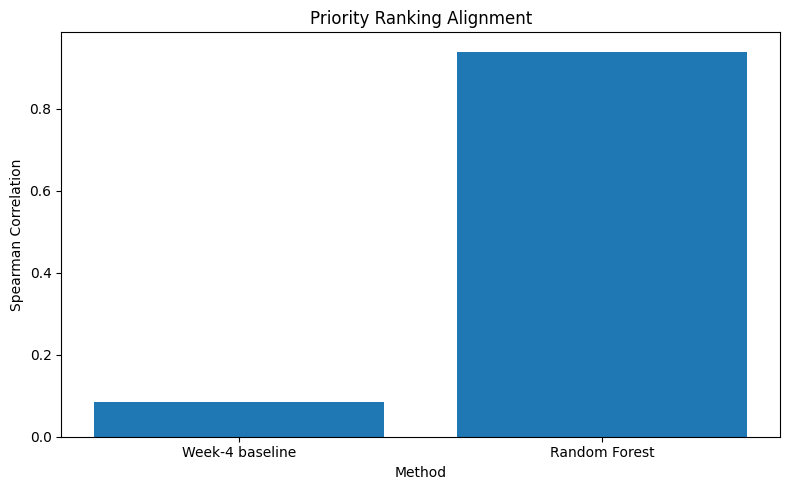

In [35]:
# --------------------------------------------------
# Model vs baseline ranking alignment
# --------------------------------------------------

plot_df = pd.DataFrame({
    "Method": [
        "Week-4 baseline",
        "Random Forest"
    ],
    "Spearman": [
        baseline_spearman,
        model_spearman
    ]
})

plt.figure(figsize=(8, 5))

plt.bar(
    plot_df["Method"],
    plot_df["Spearman"]
)

plt.title("Priority Ranking Alignment")
plt.ylabel("Spearman Correlation")
plt.xlabel("Method")

plt.tight_layout()
plt.show()

### Result interpretation

The comparison reports the observed performance of the two approaches on the same held-out client groups.

The Random Forest is considered useful for the capstone only to the extent that its ranking alignment and regression error provide useful evidence beyond the transparent baseline. A higher metric is not interpreted as proof of causal impact. The baseline remains valuable because it is simple, transparent, and easy for a content team to understand.

## 5. Limitations


This analysis has several important limitations.

First, the dataset provides observational measurements. The analysis can identify associations and directional patterns but cannot establish that changing a page will cause a particular change in search performance.

Second, the action score and model depend on the fields available in the supplied dataset. Important editorial, business, competitive, seasonal, and external factors may not be represented.

Third, the client-grouped split reduces client leakage but does not turn the analysis into a causal experiment.

Fourth, `trend_pct` is an observed outcome in the supplied data. It should not be interpreted as a guaranteed future result.

Finally, a high-ranked recommendation means that the content is worth human review under the defined scoring rule. It does not mean that a refresh is automatically required or guaranteed to improve performance.

The results should therefore be described as **observed, measured, directional, and decision-support**.

## 6. Ranked recommendations

The final action queue prioritizes content using the Week-4 baseline action score.

The highest-ranked items are recommended for human review first. Reason codes make the ranking interpretable by identifying the observed signals contributing to the recommendation.

The recommendation is a review priority, not an automatic refresh instruction.

In [36]:
# --------------------------------------------------
# Build final ranked recommendation queue
# --------------------------------------------------

recommendations = test_df[
    [
        "content_id",
        "search_volume",
        "ctr",
        "avg_position",
        "engagement_rate"
    ]
].copy()

# Fill missing values
for col in baseline_features:
    recommendations[col] = recommendations[col].fillna(
        train_df[col].median()
    )

# Recalculate baseline components
recommendations["low_ctr_score"] = (
    1 - recommendations["ctr"].rank(pct=True)
)

recommendations["poor_position_score"] = (
    recommendations["avg_position"].rank(pct=True)
)

recommendations["low_engagement_score"] = (
    1 - recommendations["engagement_rate"].rank(pct=True)
)

recommendations["high_demand_score"] = (
    recommendations["search_volume"].rank(pct=True)
)

recommendations["action_score"] = (
    0.30 * recommendations["low_ctr_score"]
    + 0.30 * recommendations["poor_position_score"]
    + 0.25 * recommendations["low_engagement_score"]
    + 0.15 * recommendations["high_demand_score"]
)

recommendations = recommendations.sort_values(
    "action_score",
    ascending=False
).reset_index(drop=True)

recommendations["rank"] = (
    np.arange(len(recommendations)) + 1
)

# Reason codes
def make_reason(row):

    reasons = []

    if row["low_ctr_score"] >= 0.75:
        reasons.append("LOW_CTR")

    if row["poor_position_score"] >= 0.75:
        reasons.append("POOR_POSITION")

    if row["low_engagement_score"] >= 0.75:
        reasons.append("LOW_ENGAGEMENT")

    if row["high_demand_score"] >= 0.75:
        reasons.append("HIGH_DEMAND")

    if len(reasons) >= 2:
        return "MULTI_SIGNAL|" + "|".join(reasons)

    if len(reasons) == 1:
        return reasons[0]

    return "GENERAL_REVIEW"

recommendations["reason_code"] = recommendations.apply(
    make_reason,
    axis=1
)

recommendations["action"] = np.where(
    recommendations["rank"] <= 20,
    "REVIEW",
    "MONITOR"
)

final_recommendations = recommendations[
    [
        "rank",
        "content_id",
        "action",
        "action_score",
        "reason_code",
        "search_volume",
        "ctr",
        "avg_position",
        "engagement_rate"
    ]
]

final_recommendations.head(20)

,rank,content_id,action,action_score,reason_code,search_volume,ctr,avg_position,engagement_rate
0,1,content_3921a7d7066d,REVIEW,0.845361,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,5400.0,0.0,74.1,0.0
1,2,content_0c0d41e86269,REVIEW,0.842669,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,8100.0,0.0,54.5,0.0
2,3,content_515bb44a0009,REVIEW,0.840800,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,4400.0,0.0,50.9,0.0
3,4,content_c13bfe497aeb,REVIEW,0.839447,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,2400.0,0.0,49.8,0.0
4,5,content_8d0a8cbf9d1e,REVIEW,0.838741,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,2900.0,0.0,47.7,0.0
5,6,content_2d517e68e168,REVIEW,0.838652,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,1600.0,0.0,50.1,0.0
6,7,content_f01fc1fb9b35,REVIEW,0.837696,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,590.0,0.0,61.7,0.0
7,8,content_4ea3bf51de39,REVIEW,0.837475,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,2400.0,0.0,46.5,0.0
8,9,content_9ecd60ff3bca,REVIEW,0.837137,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,390.0,0.0,71.3,0.0
9,10,content_8d2efba45f13,REVIEW,0.837019,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,480.0,0.0,63.1,0.0


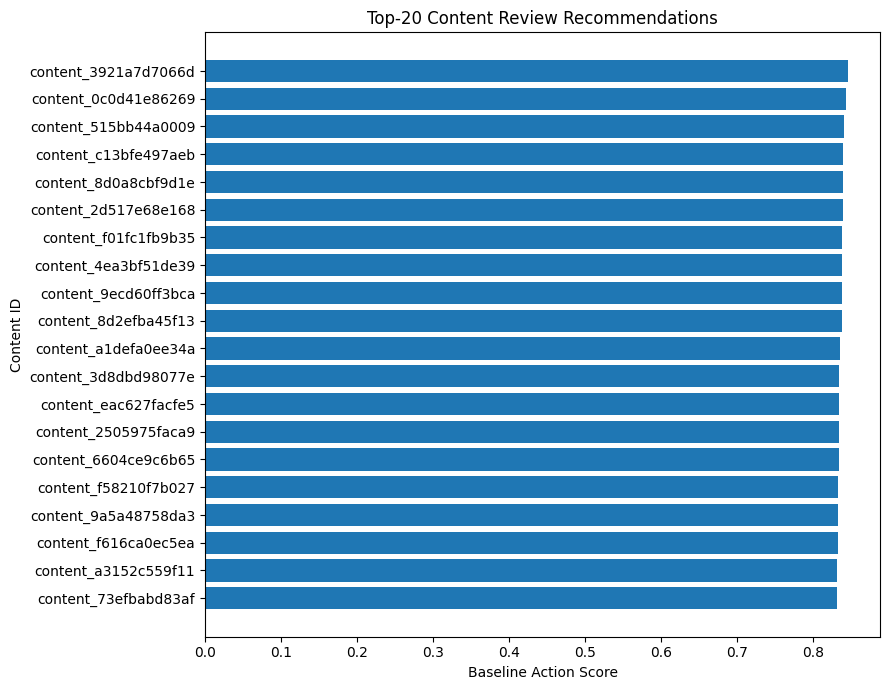

In [37]:
# --------------------------------------------------
# Top-20 recommendations
# --------------------------------------------------

top20 = final_recommendations.head(20).sort_values(
    "action_score",
    ascending=True
)

plt.figure(figsize=(9, 7))

plt.barh(
    top20["content_id"].astype(str),
    top20["action_score"]
)

plt.title("Top-20 Content Review Recommendations")
plt.xlabel("Baseline Action Score")
plt.ylabel("Content ID")

plt.tight_layout()
plt.show()

In [38]:
from pathlib import Path

output_dir = Path("work/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

recommendation_path = (
    output_dir / "capstone_ranked_recommendations.csv"
)

final_recommendations.to_csv(
    recommendation_path,
    index=False
)

print("Saved:", recommendation_path)

Saved: work/outputs/capstone_ranked_recommendations.csv


## 7. Artifacts the paper embeds


The paper should embed a small number of decision-useful artifacts rather than a large collection of charts.

The core artifacts are:

1. A model-versus-baseline comparison table.
2. A priority-ranking comparison chart.
3. A Top-20 ranked recommendation table.
4. A Top-20 action-score chart.
5. A Random Forest feature-importance chart.
6. A short error-analysis table showing the largest prediction errors.

These artifacts provide evidence for the methodology, results, and recommendations without exposing private client information.

# Feature importance artifact

In [39]:
# --------------------------------------------------
# Feature importance
# --------------------------------------------------

trained_model = model_pipeline.named_steps["model"]
trained_preprocessor = model_pipeline.named_steps["preprocessor"]

feature_names = (
    trained_preprocessor
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": trained_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

top_importance = importance_df.head(15)

top_importance

,feature,importance
15,numeric__impressions_last_30d,0.765564
18,numeric__impressions_prev_30d,0.097980
12,numeric__scroll_events_90d,0.061484
25,numeric__avg_position,0.051450
1,numeric__competition,0.004509
21,numeric__content_age_days,0.004358
40,categorical__main_intent_transactional,0.002486
24,numeric__ctr,0.002012
13,numeric__days_with_impressions,0.001575
4,numeric__char_count,0.001570


# Visualization

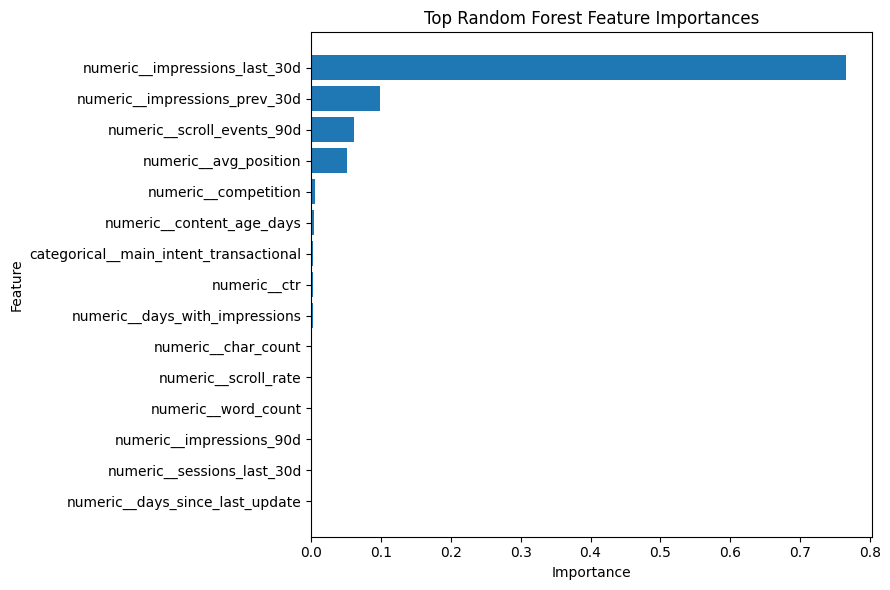

In [40]:
plt.figure(figsize=(9, 6))

importance_plot = top_importance.sort_values(
    "importance",
    ascending=True
)

plt.barh(
    importance_plot["feature"],
    importance_plot["importance"]
)

plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 8. Reproducibility

The analysis is organized as a sequence of weekly notebooks covering the data contract, leakage checks, signal audit, baseline action score, model training, and capstone results.

The repository contains the analysis notebooks under `work/` and the final paper URL under `submission/paper_url.txt`.

The main workflow is:

1. Define the unit of analysis and target.
2. Identify excluded and leakage-prone fields.
3. Audit candidate signals.
4. Build the transparent Week-4 baseline.
5. Split data by client.
6. Train the Random Forest regression model.
7. Evaluate the model and baseline on the same held-out data.
8. Generate the ranked recommendation queue.

The analysis can therefore be rerun from the supplied data and notebooks without relying on manually entered results.

In [41]:
# --------------------------------------------------
# Reproducibility summary
# --------------------------------------------------

print("Target:", TARGET)
print("Group column:", GROUP)

print("\nTraining rows:", len(train_df))
print("Test rows:", len(test_df))

print("\nModel features:", len(feature_cols))

print("\nExcluded fields:")
for col in excluded_features:
    print("-", col)

print("\nOutput files:")
print("-", recommendation_path)


Target: trend_pct
Group column: client_id

Training rows: 21514
Test rows: 5098

Model features: 37

Excluded fields:
- content_id
- client_id
- trend_pct
- trend_direction
- char_count_tier
- impression_tier
- position_tier

Output files:
- work/outputs/capstone_ranked_recommendations.csv


## 9. Acknowledgments & Data Credit

This project was completed as part of the FlyRank ML Internship.

The analysis was built on the FlyRank ML Internship dataset and follows the public-safe requirements of the internship.

**Data credit:** Built on the FlyRank ML Internship dataset.

FlyRank: https://flyrank.ai

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
